<a href="https://colab.research.google.com/github/Yxtsu-unu/CI---245---Java-II/blob/main/Lab8_KNN_MovieStore_Soledad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# lab 8 - knn classification for Video data

#Date: 5/4/26
#Soledad Rodriguez



In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [45]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
video_store_file = '/content/drive/MyDrive/CI345_ML//data/Video_Store.csv'

orginal_vtable = pd.read_csv(video_store_file)
orginal_vtable.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No
2,3,F,32000,20,42,1.6,Comedy,No


In [37]:
df = orginal_vtable.head(3)
df

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000.0,25,32,2.5,Action,Yes
1,2,F,54000.0,33,12,3.4,Drama,No
2,3,F,32000.0,20,42,1.6,Comedy,No


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Cust ID      50 non-null     int64  
 1   Gender       50 non-null     object 
 2   Income       50 non-null     float64
 3   Age          50 non-null     int64  
 4   Rentals      50 non-null     int64  
 5   AvgPerVisit  50 non-null     float64
 6   Genre        50 non-null     object 
 7   Like         50 non-null     object 
dtypes: float64(2), int64(3), object(3)
memory usage: 3.3+ KB


In [61]:
df.dtypes

,0
Cust ID,int64
Gender,object
Income,float64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,object
Like,object


In [62]:
df.isnull().sum()

,0
Cust ID,0
Gender,0
Income,0
Age,0
Rentals,0
AvgPerVisit,0
Genre,0
Like,0


In [63]:
vtable = orginal_vtable
vtable['Income'] = vtable['Income'].astype(float)
vtable
vtable.dtypes

,0
Cust ID,int64
Gender,object
Income,float64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,object
Like,object


In [64]:
print(orginal_vtable.dtypes)

Cust ID          int64
Gender          object
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre           object
Like            object
dtype: object


In [70]:
print(df['Income'].describe())
print('---------------------------------------------')
df[['Income','Age','Rentals']].describe()


count       50.000000
mean     42300.000000
std      21409.753642
min       1000.000000
25%      26750.000000
50%      41000.000000
75%      56750.000000
max      89000.000000
Name: Income, dtype: float64
---------------------------------------------


,Income,Age,Rentals
count,50.000000,50.000000,50.000000
mean,42300.000000,31.560000,26.320000
std,21409.753642,12.000272,10.047723
min,1000.000000,15.000000,9.000000
25%,26750.000000,22.000000,19.000000
50%,41000.000000,30.000000,25.000000
75%,56750.000000,37.500000,32.000000
max,89000.000000,70.000000,48.000000


In [75]:
df = orginal_vtable
df.head(2)

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000.0,25,32,2.5,Action,Yes
1,2,F,54000.0,33,12,3.4,Drama,No


Genre
Drama     20
Action    18
Comedy    12
Name: count, dtype: int64
-----------------------------------


<Axes: xlabel='Genre'>

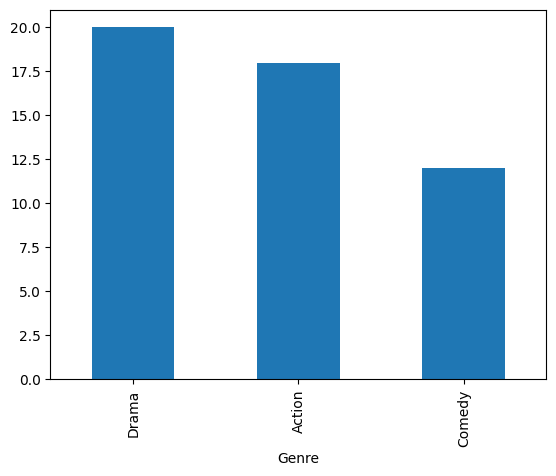

In [78]:
res = df['Genre'].value_counts()
print(res)
print('-----------------------------------')
res.plot(kind = 'bar')

<Axes: title={'center': 'Income'}, ylabel='Frequency'>

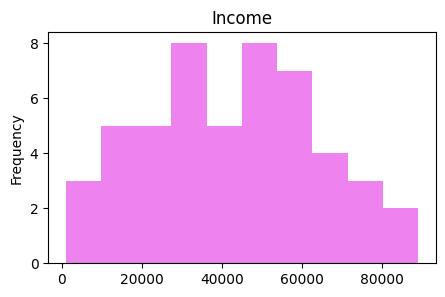

In [96]:
df = orginal_vtable
res = df['Income']
res.plot(kind = 'hist', title = 'Income', color = 'violet', figsize = (5,3))

In [31]:
res = df['Like'].value_counts()


array([[<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Rentals'}>,
        <Axes: title={'center': 'AvgPerVisit'}>]], dtype=object)

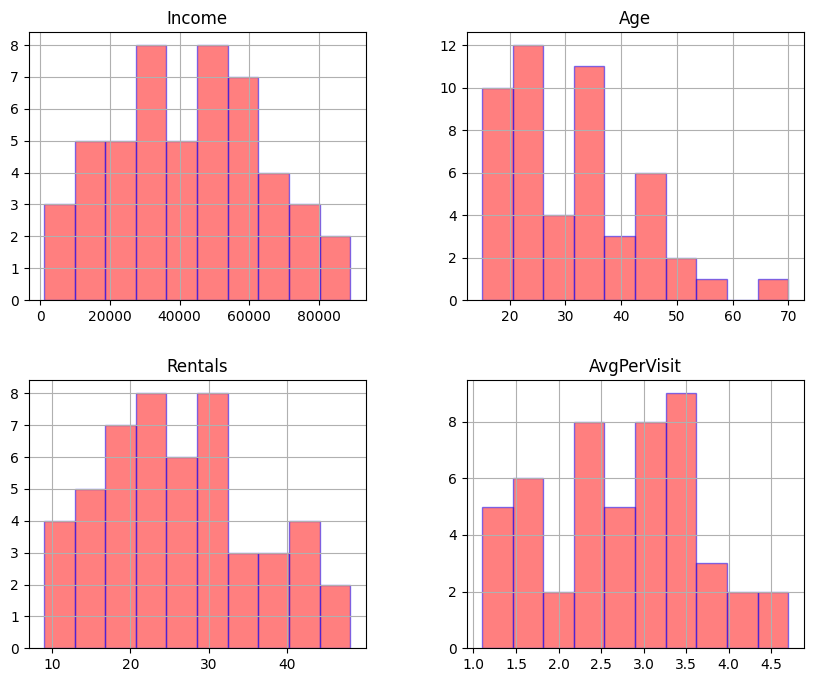

In [107]:
print('Lab8 - Soledad Rodriguez')
df = orginal_vtable
res = df[['Income','Age','Rentals','AvgPerVisit']]

res.hist(alpha = 0.5, color = 'red', edgecolor = 'blue',figsize = (10,8))


In [32]:
df.head(2)

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000.0,25,32,2.5,Action,Yes
1,2,F,54000.0,33,12,3.4,Drama,No


In [33]:
# Need Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 1 : Using LabelEncoder
# Problem: model may think numbers have order (0 < 1 < 2)
# Use mainly for target labels (y), not features

print('--------')
df = orginal_vtable
from sklearn.preprocessing import LabelEncoder

# All category feature need to transfer to numeric feature
encoder = LabelEncoder()
df= df.apply(encoder.fit_transform)
print(df.dtypes)
print(df.head(2))

# vs Method


print(df.dtypes)
df.head(2)

--------
Cust ID        int64
Gender         int64
Income         int64
Age            int64
Rentals        int64
AvgPerVisit    int64
Genre          int64
Like           int64
dtype: object
   Cust ID  Gender  Income  Age  Rentals  AvgPerVisit  Genre  Like
0        0       1      19    8       20           10      0     1
1        1       0      24   13        2           18      2     0
Cust ID        int64
Gender         int64
Income         int64
Age            int64
Rentals        int64
AvgPerVisit    int64
Genre          int64
Like           int64
dtype: object


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,0,1,19,8,20,10,0,1
1,1,0,24,13,2,18,2,0


In [34]:
# Current process data has not category
vtable = df_use_LabelEncoder
# Seperate data part
v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]
# Get target
v_target = vtable['Like']

print(v_data.shape)
print(v_target.shape)
v_data.head(3)

NameError: name 'df_use_LabelEncoder' is not defined

In [ ]:
# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)


# Converting categoric feature to numerical feature

## Method 2 : Using get_dummies -

In [ ]:
# Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies
df = orginal_vtable
print(df.head(2))
gender_df= pd.get_dummies(df['Gender'])

v_matrix = pd.get_dummies(orginal_vtable)
print(v_matrix.dtypes)
print(v_matrix.head(2))

v_matrix = v_matrix.astype(int)
print(v_matrix.head(2))

# Problem : numberical features also changed !!!!


In [ ]:

# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies -
df = orginal_vtable


# Drop duplicated columns


print(df_use_dummies.shape)
df_use_dummies.head(2)


In [ ]:
# Seperate data and target, after use dummies


print(all_cols)

size = len(all_cols)
#print(size)

data_cols =all_cols [0:(size-2)]
#print(data_cols)
#print(df_use_dummies.columns[0:(size-2)] )

# Seperate data part
# v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]

# Get target


print(v_data.shape)
print(v_target.shape)


In [ ]:
v_data.head(2)

In [ ]:
v_target.head(2)

In [ ]:
data_train.describe()

In [ ]:
# After using use_dummies

# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

# Convert categoric feature to numerical feature

## Method 3 : Using HotOneEncoder


In [ ]:
#use scores method
score = knn_classifier.score(v_test_norm, target_test)
score

In [ ]:
#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print(matrix)

In [ ]:
#Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)